# 📊 Classification Metrics: Complete Reference Guide

**A comprehensive exploration of 16+ classification metrics with intuitive analogies, formulas, and practical code**

---

## Table of Contents

1. [Business Context: Spam Detection](#1-business-context-spam-detection)
2. [The Problem with Accuracy](#2-the-problem-with-accuracy)
3. [Confusion Matrix](#3-confusion-matrix)
4. [Precision](#4-precision)
5. [Recall (Sensitivity)](#5-recall-sensitivity)
6. [F1 Score](#6-f1-score)
7. [F-beta Score](#7-f-beta-score)
8. [Threshold Optimization](#8-threshold-optimization)
9. [Specificity & Related Rates](#9-specificity--related-rates)
10. [Top-k Accuracy](#10-top-k-accuracy)
11. [Average Precision & MAP](#11-average-precision--map)
12. [ROC AUC](#12-roc-auc)
13. [PR AUC](#13-pr-auc)
14. [Balanced Accuracy](#14-balanced-accuracy)
15. [Cohen's Kappa](#15-cohens-kappa)
16. [Hamming Loss](#16-hamming-loss)
17. [Jaccard Index](#17-jaccard-index)
18. [Matthews Correlation Coefficient (MCC)](#18-matthews-correlation-coefficient-mcc)
19. [Quick Reference](#quick-reference)

---

## 1. Business Context: Spam Detection

<img src='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/085/721/original/download.png?1723456062' width=700>

### The Problem Setup

We're building a spam detection model with an **imbalanced dataset**:
- **Not Spam (Class 0)** ≈ 70% of data
- **Spam (Class 1)** ≈ 30% of data

### Key Insight

When data is imbalanced, **accuracy alone is misleading**. A model that predicts "Not Spam" for everything achieves ~70% accuracy while being completely useless!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_auc_score, 
                             roc_curve, precision_recall_curve, 
                             average_precision_score, ConfusionMatrixDisplay)

---

## 2. The Problem with Accuracy

<img src='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/061/888/original/z.png?1705233125' width=700>

### Why Accuracy Fails

1. **Accuracy doesn't work with imbalanced datasets**
2. **Lacks class-wise/granular insight** — we care specifically about catching spam!

> **💡 Sticky Analogy: The Lazy Security Guard**
> 
> A security guard who says "No threat!" to everyone still gets 99% accuracy if only 1% of visitors are dangerous. But he's completely useless!

### The Dumb Model Problem

A model that **always predicts the majority class** achieves high accuracy but:
- **Catches zero spam** (TP = 0)
- Is completely useless for our business goal

---

## 3. Confusion Matrix

<img src='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/061/898/original/z.png?1705233352' width=700>

### The Four Quadrants

| | **Predicted: Negative (0)** | **Predicted: Positive (1)** |
|---|---|---|
| **Actual: Negative (0)** | True Negative (TN) ✅ | False Positive (FP) ❌ |
| **Actual: Positive (1)** | False Negative (FN) ❌ | True Positive (TP) ✅ |

### Definitions

- **True Positive (TP):** \(\hat{y} = 1\), \(y = 1\) — Correctly identified spam
- **True Negative (TN):** \(\hat{y} = 0\), \(y = 0\) — Correctly identified non-spam  
- **False Positive (FP):** \(\hat{y} = 1\), \(y = 0\) — Wrongly marked as spam (Type I Error)
- **False Negative (FN):** \(\hat{y} = 0\), \(y = 1\) — Spam slipped through (Type II Error)

> **📧 Real-World Impact:**
> - **FP:** Your boss's promotion email goes to spam folder! 😬
> - **FN:** A phishing attack reaches your inbox! 😱

In [ ]:
# Confusion Matrix Code
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Example predictions
y_true = [0, 0, 0, 1, 1, 1, 1, 0, 1, 0]
y_pred = [0, 0, 1, 1, 1, 0, 1, 0, 1, 0]

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Extract values
TN, FP, FN, TP = cm.ravel()
print(f"\nTP={TP}, TN={TN}, FP={FP}, FN={FN}")

Confusion Matrix:
[[4 1]
 [1 4]]

TP=4, TN=4, FP=1, FN=1


---

## 4. Precision

<img src='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/061/892/original/z.png?1705233192' width=700>

### Formula

$$\text{Precision} = \frac{TP}{TP + FP}$$

### The Question It Answers

**"When the model says 'Spam', how often is it actually spam?"**

> **👮 Sticky Analogy: The Overeager Security Guard**
>
> A paranoid guard stops 100 people, accusing all of being intruders:
> - 20 were actually intruders ✅
> - 80 had valid tickets ❌
>
> **Precision = 20/100 = 20%** — Only 20% of his accusations were correct!

### When to Use Precision

When **False Positives are costly**:
- Email spam filter (don't block important emails!)
- Recommendation systems (don't annoy users with bad recommendations)

In [ ]:
# Precision Calculation
from sklearn.metrics import precision_score

# Scratch implementation
def precision_calc(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tp = cm[1, 1]
    fp = cm[0, 1]
    return tp / (tp + fp)

# Using sklearn
precision = precision_score(y_true, y_pred)
print(f"Precision: {precision:.3f}")
print(f"Interpretation: When model says 'Spam', it's correct {precision*100:.1f}% of the time")

Precision: 0.800
Interpretation: When model says 'Spam', it's correct 80.0% of the time


---

## 5. Recall (Sensitivity)

<img src='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/061/928/original/z.png?1705234684' width=700>

### Formula

$$\text{Recall} = \frac{TP}{TP + FN}$$

### The Question It Answers

**"Of all the actual spam emails, how many did we catch?"**

> **😴 Sticky Analogy: The Lazy Security Guard**
>
> A conservative guard only stops people he's **absolutely sure** are intruders:
> - 50 actual intruders tried to sneak in
> - He only stopped 10 (all genuine intruders — great precision!)
> - But **40 intruders walked right past him!**
>
> **Recall = 10/50 = 20%** — He only caught 20% of the intruders!

### When to Use Recall

When **False Negatives are costly**:
- Cancer detection (don't miss a patient with cancer!)
- Fraud detection (don't let fraud slip through!)
- Airport security (don't let dangerous people board!)

In [ ]:
# Recall Calculation
from sklearn.metrics import recall_score

# Scratch implementation
def recall_calc(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tp = cm[1, 1]
    fn = cm[1, 0]
    return tp / (tp + fn)

# Using sklearn
recall = recall_score(y_true, y_pred)
print(f"Recall: {recall:.3f}")
print(f"Interpretation: We caught {recall*100:.1f}% of all actual spam")

Recall: 0.800
Interpretation: We caught 80.0% of all actual spam


### Precision vs Recall: Key Difference

| Metric | Question | Looks at... |
|--------|----------|-------------|
| **Precision** | "When I say Spam, am I right?" | **Predicted Spam** column |
| **Recall** | "Did I catch all the Spam?" | **Actually Spam** row |

---

## 6. F1 Score

### The Problem: Precision-Recall Trade-off

You can game individual metrics:
- **High Recall, Low Precision:** Predict everything as positive
- **High Precision, Low Recall:** Only predict when 100% confident

### Formula (Harmonic Mean)

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

> **⚖️ Sticky Analogy: The Balanced Diet**
>
> If you eat only protein (Precision) or only carbs (Recall), you're unhealthy.
> F1 Score is like your nutritionist saying: "You need BOTH in balance!"
>
> The harmonic mean punishes imbalance — having 90% precision but 10% recall gives you a low F1.

### Why Harmonic Mean?

- **Arithmetic mean** of 90% and 10% = 50% (too generous!)
- **Harmonic mean** of 90% and 10% = 18% (exposes the weakness!)

In [ ]:
# F1 Score Calculation
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

Precision: 0.800
Recall: 0.800
F1 Score: 0.800


---

## 7. F-beta Score

### When F1 Isn't Enough

What if you care **more about one type of error**?

### Formula

$$F_\beta = (1 + \beta^2) \times \frac{\text{Precision} \times \text{Recall}}{(\beta^2 \times \text{Precision}) + \text{Recall}}$$

### Understanding Beta Values

| Beta | Emphasis | Example Use Case |
|------|----------|------------------|
| **β = 0.5** | Precision 2x more important | Spam filtering (don't block good emails) |
| **β = 1.0** | Equal weight (F1 Score) | Balanced importance |
| **β = 2.0** | Recall 2x more important | Cancer screening (don't miss any cases) |

> **🏥 Sticky Analogy: The Cancer Screening Dial**
>
> - β < 1: "I'd rather miss some cancer cases than cause panic with false alarms"
> - β = 1: "Both errors are equally bad"
> - β > 2: "I'd rather have false alarms than miss a single cancer case!"

In [ ]:
# F-beta Score Calculation
from sklearn.metrics import fbeta_score

f05 = fbeta_score(y_true, y_pred, beta=0.5)  # Precision-focused
f1 = fbeta_score(y_true, y_pred, beta=1.0)   # Balanced
f2 = fbeta_score(y_true, y_pred, beta=2.0)   # Recall-focused

print(f"F0.5 (Precision-focused): {f05:.3f}")
print(f"F1 (Balanced): {f1:.3f}")
print(f"F2 (Recall-focused): {f2:.3f}")

F0.5 (Precision-focused): 0.800
F1 (Balanced): 0.800
F2 (Recall-focused): 0.800


---

## 8. Threshold Optimization

### The Key Insight

Models output **probabilities** (0.7, 0.3, etc.). The default threshold is 0.5, but this isn't always optimal!

### How Threshold Affects Metrics

| Threshold | Effect |
|-----------|--------|
| **Higher (e.g., 0.7)** | More conservative → Higher Precision, Lower Recall |
| **Lower (e.g., 0.3)** | More aggressive → Higher Recall, Lower Precision |

> **🦁 Sticky Analogy: The Cautious Banker**
>
> "I'd rather reject 10 good customers than give a loan to 1 person who won't pay me back."
>
> → **Lower threshold** = More paranoid = Catches more defaulters = Higher recall

In [ ]:
# Threshold Optimization Code
def find_optimal_threshold(y_true, y_scores, metric='f1'):
    """Find threshold that maximizes chosen metric"""
    thresholds = np.linspace(0.01, 0.99, 50)
    best_score, best_threshold = -1, -1
    
    for threshold in thresholds:
        y_pred = (np.array(y_scores) >= threshold).astype(int)
        
        if metric == 'f1':
            score = f1_score(y_true, y_pred)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred)
        elif metric == 'precision':
            score = precision_score(y_true, y_pred)
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
    
    return best_threshold, best_score

# Example
y_scores_example = [0.9, 0.2, 0.8, 0.7, 0.6, 0.4, 0.9, 0.3, 0.85, 0.1]
y_true_example = [1, 0, 1, 1, 1, 0, 1, 0, 1, 0]

threshold, score = find_optimal_threshold(y_true_example, y_scores_example, 'f1')
print(f"Optimal threshold for F1: {threshold:.2f} (F1 Score: {score:.3f})")

Optimal threshold for F1: 0.41 (F1 Score: 1.000)


---

## 9. Specificity & Related Rates

### Aliases and Formulas

| Metric | Formula | Also Called | The Question |
|--------|---------|-------------|---------------|
| **True Positive Rate (TPR)** | \(\frac{TP}{TP+FN}\) | Sensitivity, Recall | "Of actual positives, how many did we catch?" |
| **False Positive Rate (FPR)** | \(\frac{FP}{FP+TN}\) | 1 - Specificity, Fall-out | "Of actual negatives, how many did we wrongly flag?" |
| **Specificity** | \(\frac{TN}{TN+FP}\) | True Negative Rate (TNR) | "Of actual negatives, how many did we correctly identify?" |
| **Precision** | \(\frac{TP}{TP+FP}\) | Positive Predictive Value (PPV) | "When we say 'yes', how often are we right?" |

### Worked Example

**100 people: 10 sick, 90 healthy**

Test results:
- 8 sick correctly identified (TP)
- 2 sick missed (FN)
- 15 healthy wrongly flagged (FP)
- 75 healthy correctly identified (TN)

| Metric | Calculation | Result |
|--------|-------------|--------|
| **TPR (Recall)** | 8/(8+2) | 80% |
| **FPR** | 15/(15+75) | 16.7% |
| **Specificity** | 75/(75+15) | 83.3% |
| **Precision** | 8/(8+15) | 34.8% |

---

## 10. Top-k Accuracy

### The Concept

**Top-k accuracy** gives credit if the correct answer appears anywhere in the top k predictions.

> **🎮 Sticky Analogy: The Quiz Show with Multiple Guesses**
>
> "What breed is this dog?"
> - Top-1: "Labrador" ❌ (wrong)
> - Top-3: "Labrador, **Golden Retriever**, German Shepherd" ✅ (correct answer in top 3!)
>
> Top-1 accuracy = 0%, Top-3 accuracy = 100%

### When to Use

- Multi-class problems with **similar classes** (dog breeds, product categories)
- Search engines and recommendation systems
- When being "close" matters

In [ ]:
# Top-k Accuracy
from sklearn.metrics import top_k_accuracy_score

# Example: 3-class problem
y_true_multi = [0, 1, 2, 0, 1]
y_scores_multi = [
    [0.8, 0.1, 0.1],  # Class 0 predicted
    [0.4, 0.3, 0.3],  # Class 0 predicted (wrong!)
    [0.2, 0.3, 0.5],  # Class 2 predicted
    [0.6, 0.3, 0.1],  # Class 0 predicted
    [0.1, 0.8, 0.1],  # Class 1 predicted
]

top1 = top_k_accuracy_score(y_true_multi, y_scores_multi, k=1)
top2 = top_k_accuracy_score(y_true_multi, y_scores_multi, k=2)

print(f"Top-1 Accuracy: {top1:.1%}")
print(f"Top-2 Accuracy: {top2:.1%}")

Top-1 Accuracy: 80.0%
Top-2 Accuracy: 80.0%


---

## 11. Average Precision & MAP

### The Problem with Precision@k

Precision@k doesn't capture **ranking order**!

| Engine | Results | Precision@5 |
|--------|---------|-------------|
| A | 🍕🍕🍕❌❌ | 3/5 = 60% |
| B | ❌❌🍕🍕🍕 | 3/5 = 60% |

Same score, but **Engine A is clearly better** — good results first!

> **🎣 Sticky Analogy: The Fishing Competition**
>
> You're fishing for **golden fish** 🐠 among regular fish 🐟.
>
> - **Precision@k:** "After k catches, how many are golden?"
> - **AP:** "Average your precision ONLY when you catch a golden fish"
> - **MAP:** "Your average score across multiple fishing trips"

### The Hand Trick 🖐️

- **Precision@k** = Count ALL fingers up to k → "How many have rings?"
- **AP** = Only look at fingers WITH rings → "Average the position of each ring"
- **MAP** = Do this for BOTH hands → "Average across multiple hands"

### Formula

$$AP = \frac{1}{\text{Total Relevant}} \sum_{k=1}^{n} (Precision@k \times Relevance_k)$$

In [ ]:
# Average Precision
from sklearn.metrics import average_precision_score

y_true_ap = [1, 0, 1, 0, 1, 0, 0, 0, 0, 0]
y_scores_ap = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05]

ap = average_precision_score(y_true_ap, y_scores_ap)
print(f"Average Precision: {ap:.3f}")

Average Precision: 0.756


---

## 12. ROC AUC

### What is ROC?

**ROC (Receiver Operating Characteristic)** plots TPR vs FPR at different thresholds.

### The Probabilistic Interpretation ✨

> **"If I randomly pick ONE positive and ONE negative, what's the probability my model ranks the positive higher?"**

| AUC | Meaning |
|-----|--------|
| 1.0 | Perfect — positive ALWAYS ranked higher |
| 0.5 | Random — 50/50 coin flip |
| 0.85 | Good — 85% chance positive ranked higher |

> **🎴 Sticky Analogy: The Card Sorting Game**
>
> You have 3 red cards ♥️ (positives) and 7 blue cards 💙 (negatives).
> 
> **Perfect model (AUC = 1.0):**
> ```
> ♥️ ♥️ ♥️ 💙 💙 💙 💙 💙 💙 💙
> ```
> All reds before all blues!
>
> **Random model (AUC = 0.5):**
> ```
> 💙 ♥️ 💙 💙 ♥️ 💙 💙 ♥️ 💙 💙
> ```
> Mixed randomly.

AUC: 0.86


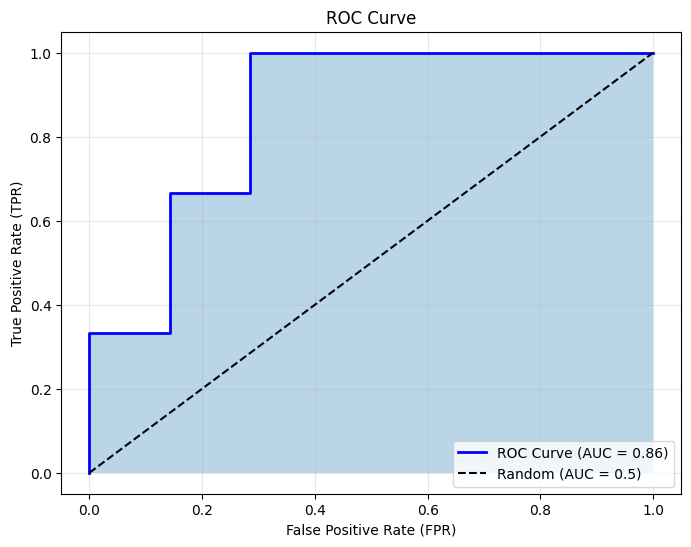

In [ ]:
# ROC AUC Calculation and Visualization
from sklearn.metrics import roc_auc_score, roc_curve

# Hospital example
y_true_roc = [1, 0, 1, 0, 1, 0, 0, 0, 0, 0]
y_scores_roc = [0.95, 0.85, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10]

# Calculate AUC
auc = roc_auc_score(y_true_roc, y_scores_roc)
print(f"AUC: {auc:.2f}")

# Get curve points
fpr, tpr, thresholds = roc_curve(y_true_roc, y_scores_roc)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### Interpreting AUC

| AUC Range | Interpretation |
|-----------|---------------|
| 0.5 | No better than random |
| 0.7-0.8 | Acceptable discrimination |
| 0.8-0.9 | Excellent discrimination |
| > 0.9 | Outstanding discrimination |

---

## 13. PR AUC

### When ROC AUC Lies

ROC AUC can be **misleading with highly imbalanced data** because FPR denominator (TN + FP) is dominated by the large negative class.

> **💎 Sticky Analogy: The Gem Inspector**
>
> Mining operation: 1000 samples, only 10 diamonds, 990 rocks.
>
> **Inspector A:** Finds 8 diamonds, also flags 12 rocks as diamonds
> - FPR = 12/990 = **1.2%** — looks amazing!
>
> **But wait:**
> - Precision = 8/20 = **40%** — exposes the problem!
>
> **"Precision only cares about YOUR picks — it doesn't care how big the haystack is."**

### When to Use

| Metric | Best For |
|--------|----------|
| **ROC AUC** | Balanced or moderately imbalanced data |
| **PR AUC** | Highly imbalanced data (rare events) |

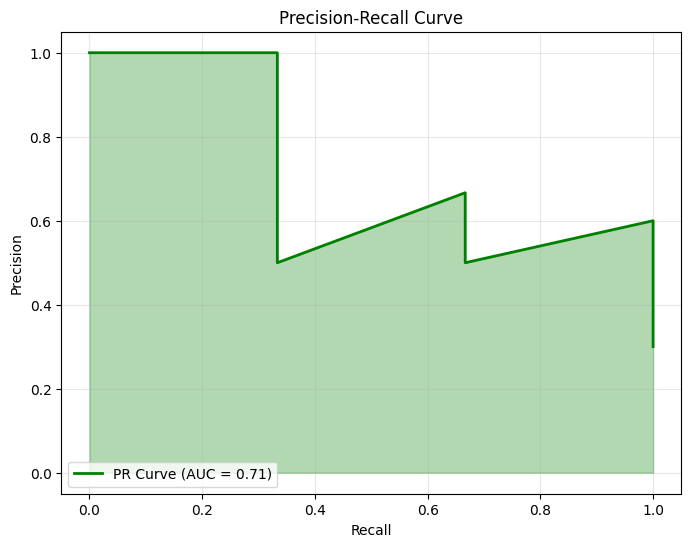

In [ ]:
# PR AUC Calculation
from sklearn.metrics import precision_recall_curve, auc

precision_vals, recall_vals, _ = precision_recall_curve(y_true_roc, y_scores_roc)
pr_auc = auc(recall_vals, precision_vals)

# print(f"ROC AUC: {auc:.2f}")
# print(f"PR AUC: {pr_auc:.2f}")

# Plot PR Curve
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, 'g-', linewidth=2, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.3, color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

---

## 14. Balanced Accuracy

### The Problem

Regular accuracy is skewed by the majority class.

### Formula

$$\text{Balanced Accuracy} = \frac{\text{TPR} + \text{TNR}}{2} = \frac{\text{Sensitivity} + \text{Specificity}}{2}$$

> **⚖️ Sticky Analogy: The Fair Judge**
>
> A judge evaluates performers from two cities:
> - City A: 100 performers
> - City B: 10 performers
>
> **Regular accuracy:** City A dominates the score
> 
> **Balanced accuracy:** "How well did you do on City A? How well on City B? Average those!"

### When to Use

- Imbalanced datasets
- When performance on **both classes matters equally**

In [ ]:
# Balanced Accuracy
from sklearn.metrics import balanced_accuracy_score

# Imbalanced example
y_true_imb = [0]*90 + [1]*10
y_pred_imb = [0]*100  # Lazy model predicts all 0

acc = accuracy_score(y_true_imb, y_pred_imb)
bal_acc = balanced_accuracy_score(y_true_imb, y_pred_imb)

print(f"Regular Accuracy: {acc:.1%}")
print(f"Balanced Accuracy: {bal_acc:.1%}")
print("\nBalanced accuracy exposes the lazy model!")

Regular Accuracy: 90.0%
Balanced Accuracy: 50.0%

Balanced accuracy exposes the lazy model!


---

## 15. Cohen's Kappa

### The Problem

Simple agreement percentage doesn't account for **agreement by chance**.

Two lazy labelers guessing "Cat" for everything = 100% agreement!

### Formula

$$\kappa = \frac{\text{Observed Agreement} - \text{Expected by Chance}}{1 - \text{Expected by Chance}}$$

> **🎲 Sticky Analogy: The Honest Referee**
>
> Two doctors diagnosing 100 patients:
> - They agree on 75 cases → 75% agreement
> - But if both say "sick" 50% of the time randomly, chance agreement = 50%
>
> **Kappa = (75% - 50%) / (100% - 50%) = 0.50**
>
> "Kappa only gives points for REAL teamwork, not lucky coincidences!"

### Interpretation

| Kappa | Meaning |
|-------|--------|
| < 0 | Worse than chance |
| 0.0 | Same as random guessing |
| 0.4-0.6 | Moderate agreement |
| 0.6-0.8 | Substantial agreement |
| 0.8-1.0 | Almost perfect agreement |

In [ ]:
# Cohen's Kappa
from sklearn.metrics import cohen_kappa_score

rater1 = [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]
rater2 = [0, 1, 0, 0, 1, 0, 1, 1, 1, 0]

kappa = cohen_kappa_score(rater1, rater2)
print(f"Cohen's Kappa: {kappa:.3f}")

Cohen's Kappa: 0.600


---

## 16. Hamming Loss

### The Multi-Label Problem

What if an example can have **multiple labels** at once?

Example: A movie can be **Action + Comedy + Sci-Fi** simultaneously!

### Formula

$$\text{Hamming Loss} = \frac{\text{Incorrect Labels}}{\text{Total Labels}}$$

> **📚 Sticky Analogy: Document Classification**
>
> A "Quantum Mechanics" paper should be labeled: **Math + Physics**
>
> **Regular accuracy:** One wrong label = FAIL the whole prediction
> 
> **Hamming Loss:** "You got 3 out of 4 labels right — that's 75%!"
>
> **"The Fair Teacher gives partial credit!"**

### Example

| Subject | True | Predicted | Correct? |
|---------|------|-----------|----------|
| Math | ✅ | ✅ | ✓ |
| Physics | ✅ | ❌ | ✗ |
| Chemistry | ❌ | ❌ | ✓ |
| Biology | ❌ | ✅ | ✗ |

**Hamming Loss = 2/4 = 0.50** (Lower is better)

In [ ]:
# Hamming Loss
from sklearn.metrics import hamming_loss

# Multi-label example (each row = one document, each column = one label)
y_true_ml = [[1, 1, 0, 0],   # Math, Physics
             [1, 0, 1, 0],   # Math, Chemistry
             [0, 0, 0, 1]]   # Biology

y_pred_ml = [[1, 0, 0, 1],   # Math, Biology (missed Physics, added Biology)
             [1, 0, 1, 0],   # Correct!
             [0, 0, 1, 1]]   # Chemistry, Biology (added Chemistry)

loss = hamming_loss(y_true_ml, y_pred_ml)
print(f"Hamming Loss: {loss:.3f}")
print(f"Hamming Accuracy: {1-loss:.1%}")

Hamming Loss: 0.250
Hamming Accuracy: 75.0%


---

## 17. Jaccard Index

### The Problem with Hamming Loss

With **many possible labels**, Hamming Loss gets distracted by labels you correctly DIDN'T assign.

> **🛒 Sticky Analogy: E-commerce Product Tags**
>
> 10,000 possible tags for a handbag:
> - **True:** {Leather, Black, Gucci}
> - **Predicted:** {Leather, Black, Prada}
>
> **Hamming Loss:** "You got 9,998 tags right!" (misleading!)
>
> **Jaccard:** "Of the tags that matter, you got 2/4 = 50%" (honest!)

### Formula

$$\text{Jaccard} = \frac{|True \cap Predicted|}{|True \cup Predicted|} = \frac{\text{Intersection}}{\text{Union}}$$

### Key Difference

| Metric | Considers |
|--------|----------|
| **Hamming Loss** | ALL possible labels (even absent ones) |
| **Jaccard** | Only labels that APPEAR in true OR predicted |

In [ ]:
# Jaccard Score
from sklearn.metrics import jaccard_score

jaccard = jaccard_score(y_true_ml, y_pred_ml, average='samples')
print(f"Jaccard Score (samples): {jaccard:.3f}")

Jaccard Score (samples): 0.611


---

## 18. Matthews Correlation Coefficient (MCC)

### The Problem MCC Solves

Remember all the issues?
- Accuracy fails with imbalanced data
- Precision ignores False Negatives
- Recall ignores False Positives
- F1 ignores True Negatives

**MCC uses ALL FOUR values:** TP, TN, FP, FN

### Formula

$$MCC = \frac{TP \times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

> **🎯 Sticky Analogy: The Complete Judge**
>
> Imagine hiring a judge for a talent show:
> - **Accuracy:** "How many decisions were correct?" (fooled by imbalance)
> - **Precision:** "When you said YES, were you right?" (ignores missed talent)
> - **Recall:** "Did you find all the talent?" (ignores false alarms)
> - **MCC:** "Overall, how well did your YES/NO decisions correlate with actual talent?"
>
> **MCC is the complete judge — considers everything!**

### Interpretation

| MCC | Meaning |
|-----|--------|
| +1 | Perfect prediction |
| 0 | Random guessing |
| -1 | Perfectly WRONG (flip predictions to be perfect!) |

### Factory Example

1000 phones: 980 good, 20 defective

| Inspector | Strategy | Accuracy | MCC |
|-----------|----------|----------|-----|
| A (Lazy) | Says "all good" | **98%** | **0** |
| B (Works) | Catches 18/20 defects, 30 false alarms | **96.8%** | **0.47** |

**MCC exposes that Inspector B is actually doing real work!**

In [ ]:
# Matthews Correlation Coefficient
from sklearn.metrics import matthews_corrcoef

# Imbalanced factory example
y_true_factory = [0]*980 + [1]*20  # 980 good, 20 defective

# Inspector A: Lazy (predicts all good)
y_pred_lazy = [0]*1000

# Inspector B: Works hard (catches 18 defects, 30 false alarms)
y_pred_works = [0]*950 + [1]*30 + [0]*2 + [1]*18  # Simplified

mcc_lazy = matthews_corrcoef(y_true_factory, y_pred_lazy)
acc_lazy = accuracy_score(y_true_factory, y_pred_lazy)

print(f"Inspector A (Lazy):")
print(f"  Accuracy: {acc_lazy:.1%}")
print(f"  MCC: {mcc_lazy:.2f}")
print(f"\nMCC = 0 exposes the lazy model as useless!")

Inspector A (Lazy):
  Accuracy: 98.0%
  MCC: 0.00

MCC = 0 exposes the lazy model as useless!


---

# Quick Reference

## 📋 Metric Selection Guide

| Scenario | Recommended Metric(s) |
|----------|----------------------|
| Balanced data, simple classification | **Accuracy** |
| Imbalanced data | **F1, Balanced Accuracy, MCC** |
| False Positives are costly | **Precision, F0.5** |
| False Negatives are costly | **Recall, F2** |
| Comparing models (threshold-free) | **ROC AUC** |
| Highly imbalanced rare events | **PR AUC** |
| Multi-label classification | **Hamming Loss, Jaccard** |
| Inter-annotator agreement | **Cohen's Kappa** |
| Most robust single metric | **MCC** |

---

## 🎯 Sticky Analogies Cheat Sheet

| Metric | Analogy |
|--------|--------|
| **Precision** | Overeager Security Guard — stops many but includes innocents |
| **Recall** | Lazy Security Guard — only stops who he's sure of, misses many |
| **F1** | Balanced Diet — need both protein and carbs |
| **F-beta** | Cancer Screening Dial — tune for your priority |
| **ROC AUC** | Card Sorting Game — rank reds before blues |
| **PR AUC** | Gem Inspector — honest about rare finds |
| **AP/MAP** | Fishing Competition — precision at each golden fish |
| **Top-k** | Quiz Show — multiple guesses allowed |
| **Cohen's Kappa** | Honest Referee — no credit for lucky coincidences |
| **Hamming Loss** | Fair Teacher — partial credit for labels |
| **Jaccard** | E-commerce Tags — focus on what matters |
| **MCC** | Complete Judge — considers everything |

---

## 📊 Formula Quick Reference

| Metric | Formula |
|--------|--------|
| **Accuracy** | \(\frac{TP + TN}{TP + TN + FP + FN}\) |
| **Precision** | \(\frac{TP}{TP + FP}\) |
| **Recall** | \(\frac{TP}{TP + FN}\) |
| **F1** | \(2 \times \frac{Precision \times Recall}{Precision + Recall}\) |
| **Specificity** | \(\frac{TN}{TN + FP}\) |
| **FPR** | \(\frac{FP}{FP + TN}\) |
| **Balanced Acc** | \(\frac{TPR + TNR}{2}\) |

---

## 🐍 Code Import Cheat Sheet

In [ ]:
# All sklearn imports you need
from sklearn.metrics import (
    # Basic
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    
    # Confusion Matrix
    confusion_matrix,
    ConfusionMatrixDisplay,
    
    # ROC & PR
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    
    # Advanced
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    
    # Multi-label
    hamming_loss,
    jaccard_score,
    
    # Multi-class
    top_k_accuracy_score,
)

---

## 📌 Key Takeaways

1. **Never rely on accuracy alone** — especially with imbalanced data
2. **Choose metrics based on business cost** — what's worse, FP or FN?
3. **Use threshold-free metrics (AUC)** for model comparison
4. **Use PR AUC** for rare event detection
5. **MCC is the most robust** single metric for binary classification
6. **Visualize the trade-offs** — ROC and PR curves tell a story

---


In [ ]:
#| hide

import subprocess
from pathlib import Path
from dialoghelper import curr_dialog

def deploy_notebook():
    nb_name = Path(curr_dialog()['name']).name + '.ipynb'
    src = f'/app/data/{curr_dialog()["name"]}.ipynb'
    dst = '/app/data/publish/portfolio/static/'
    print(nb_name)
    
    # Copy notebook to static folder
    subprocess.run(['cp', src, dst])
    
    # Deploy with plash
    subprocess.run(['plash_deploy'], cwd='/app/data/publish/portfolio')

In [ ]:
#| hide
deploy_notebook()